In [1]:
import bt
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
carteira = ["ALUP11", "BBSE3", "BRAP4", "CMIG4", "CPFE3", "IVVB11", "PRIO3", "CPLE6", "QETH11"]

carteira = [acao + ".SA" for acao in carteira]

In [3]:
# fetch some data
data = bt.get(carteira, start='2010-01-01', end='2024-10-31')
print(data.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                            alup11sa    bbse3sa    brap4sa   cmig4sa  \
Date                                                                   
2021-08-04 00:00:00+00:00  19.773132  16.279198  20.038792  4.430339   
2021-08-05 00:00:00+00:00  19.781008  16.097221  19.015196  4.359004   
2021-08-06 00:00:00+00:00  19.725885  16.150297  18.949583  4.400303   
2021-08-09 00:00:00+00:00  19.741632  16.446009  18.799980  4.419077   
2021-08-10 00:00:00+00:00  19.568394  16.301943  18.694998  4.340230   

                             cpfe3sa    ivvb11sa    prio3sa   cple6sa  \
Date                                                                    
2021-08-04 00:00:00+00:00  19.748268  248.729996  17.272257  4.846510   
2021-08-05 00:00:00+00:00  19.263037  251.300003  17.242306  4.877087   
2021-08-06 00:00:00+00:00  19.270739  253.500000  17.441984  5.007041   
2021-08-09 00:00:00+00:00  19.386271  252.729996  17.551809  5.106417   
2021-08-10 00:00:00+00:00  19.101290  250.800003  18.6899

In [4]:
# criando a estratégia
Wallet1 = bt.Strategy('Carteira', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

In [5]:
# criando o backtest e rodando ele
test = bt.Backtest(Wallet1, data)
res = bt.run(test)

100%|██████████| 1/1 [00:00<00:00,  5.97it/s]


In [6]:
#comando para permitir que os gráficos sejam mostrados

plt.ioff()

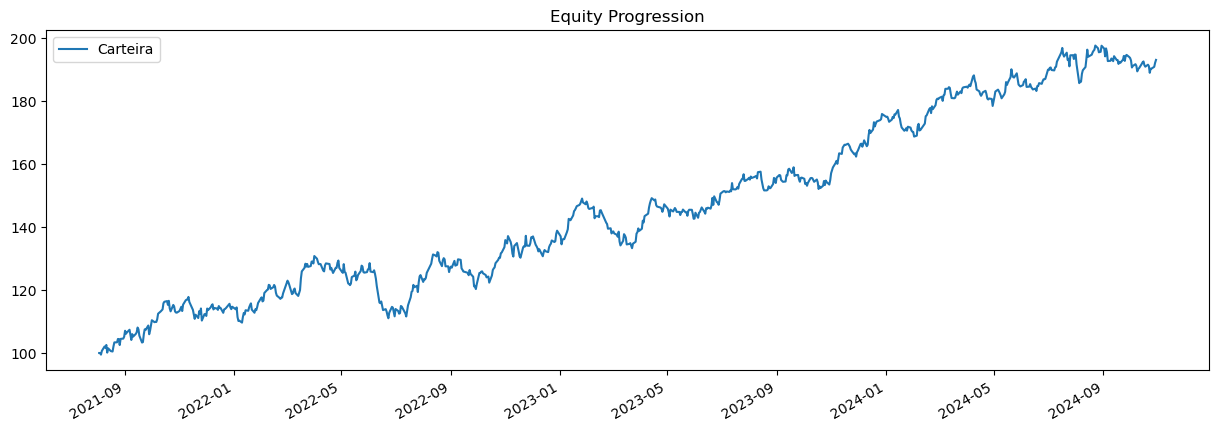

In [7]:
# plotando a curva de rentabilidade da carteira
res.plot();

plt.show()

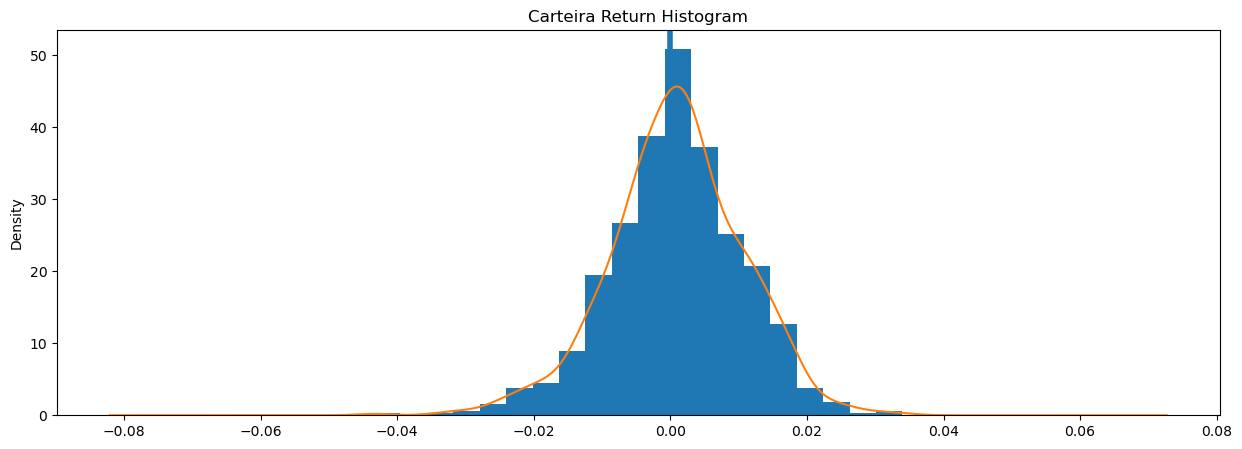

In [8]:
# ok and how does the return distribution look like?
res.plot_histogram()

plt.show()

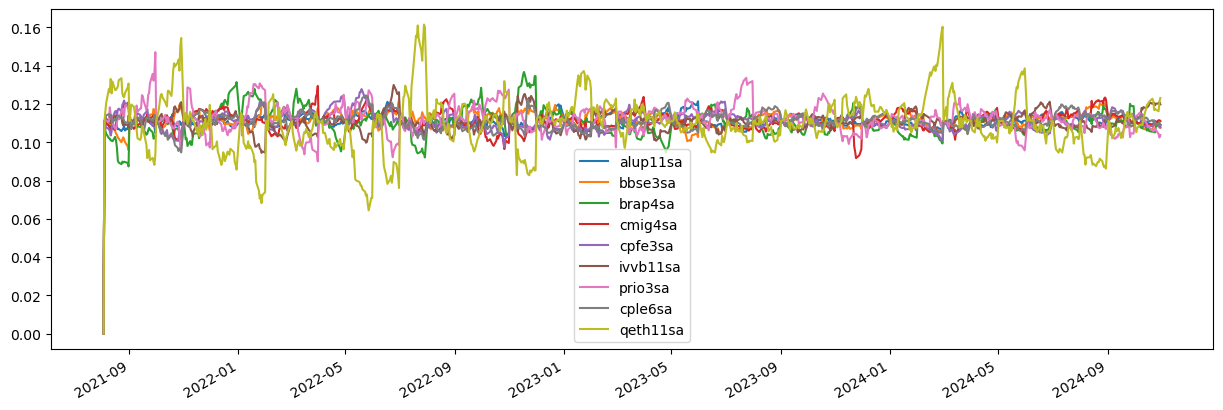

In [9]:
# and just to make sure everything went along as planned, let's plot the security weights over time
res.plot_security_weights()

plt.show()

In [10]:
# ok and what about some stats?
res.display()

Stat                 Carteira
-------------------  ----------
Start                2021-08-03
End                  2024-10-30
Risk-free rate       0.00%

Total Return         93.10%
Daily Sharpe         1.39
Daily Sortino        2.38
CAGR                 22.51%
Max Drawdown         -15.11%
Calmar Ratio         1.49

MTD                  -0.47%
3m                   -0.15%
6m                   8.19%
YTD                  9.77%
1Y                   25.79%
3Y (ann.)            19.46%
5Y (ann.)            -
10Y (ann.)           -
Since Incep. (ann.)  22.51%

Daily Sharpe         1.39
Daily Sortino        2.38
Daily Mean (ann.)    21.63%
Daily Vol (ann.)     15.52%
Daily Skew           -0.24
Daily Kurt           0.86
Best Day             3.40%
Worst Day            -4.34%

Monthly Sharpe       1.31
Monthly Sortino      2.55
Monthly Mean (ann.)  20.52%
Monthly Vol (ann.)   15.65%
Monthly Skew         -0.42
Monthly Kurt         1.32
Best Month           11.73%
Worst Month          -11.76%

Yearl